In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.csgraph import shortest_path
from sklearn.datasets import load_digits, make_s_curve, make_swiss_roll
from sklearn.manifold import Isomap
from sklearn.neighbors import BallTree
from tqdm.auto import tqdm

plt.style.use("ggplot")
plt.style.use("seaborn-v0_8-colorblind")

# Datasets

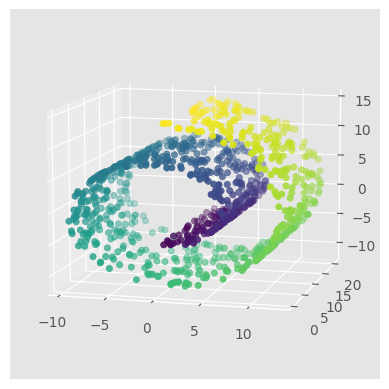

In [3]:
# digits = load_digits()
# data = digits['data']
# labels = digits['target']
# n = data.shape[0]
# data /= 255.0

data, labels = make_swiss_roll(1000)
n = data.shape[0]

# data, labels = make_s_curve(2000)
# n = data.shape[0]

ax = plt.figure().add_subplot(projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels)
ax.view_init(elev=10.0, azim=-75, roll=0)

# Sklearn reference

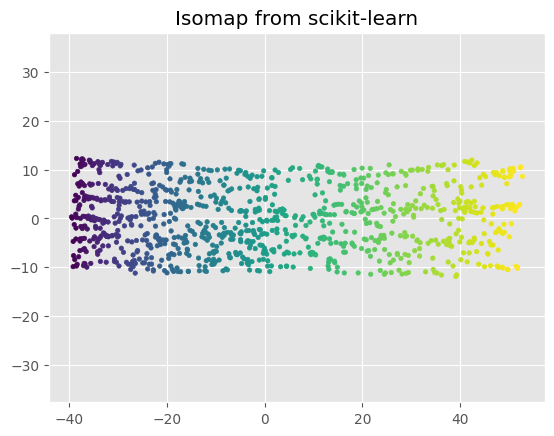

In [4]:
isomap = Isomap(n_neighbors=10)
xy = isomap.fit_transform(data)
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.title('Isomap from scikit-learn')
plt.show()

## Step 1: Neighbor Graph

In [5]:
def euclidean_pairwise_distance(data):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.

    Returns
    -------
    distances : np.ndarray of shape (n, n)
        Pairwise distance matrix, where entry (i, j) gives the distance
        between samples i and j.
    """
    diff = data[:, np.newaxis, :] - data[np.newaxis, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=2))
    return distances


def compute_graph(data, k=15, r=None):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.

    Returns
    -------
    graph_adj_matrix : np.ndarray of shape (n, n)
        Graph adjacency matrix in which each nonzero entry (i, j) stores the
        distance between connected samples i and j. Entries with value 0 indicate
        that no edge exists between the corresponding samples.
    """
    n = data.shape[0]
    euclidean_pdist = euclidean_pairwise_distance(data)

    # Initialize compute adjacency matrix
    graph_adj_matrix = np.zeros([n, n])

    if r is not None:
        # r-ball neighborhood
        mask = (euclidean_pdist <= r) & (euclidean_pdist > 0)
        graph_adj_matrix[mask] = euclidean_pdist[mask]
    else:
        # k-nearest-neighbor graph
        k = min(k, n - 1)
        neighbor_idx = np.argsort(euclidean_pdist, axis=1)[:, 1:k + 1]

        rows = np.repeat(np.arange(n), k)
        cols = neighbor_idx.reshape(-1)
        vals = euclidean_pdist[rows, cols]

        graph_adj_matrix[rows, cols] = vals
        graph_adj_matrix[cols, rows] = vals

    return graph_adj_matrix


graph_adj_matrix = compute_graph(data, k=10)
graph_adj_matrix

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        2.79622427],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 2.79622427, 0.        ,
        0.        ]], shape=(1000, 1000))

## Step 2: Shortest Path (given)

In [6]:
shortest_path_distance = shortest_path(graph_adj_matrix)
shortest_path_distance

array([[ 0.        , 34.06279116, 18.21798458, ..., 14.00493898,
        12.86314891, 16.60270115],
       [34.06279116,  0.        , 47.04727911, ..., 20.60868084,
        43.25064295, 17.81245657],
       [18.21798458, 47.04727911,  0.        , ..., 27.86612415,
         5.68730857, 30.66234841],
       ...,
       [14.00493898, 20.60868084, 27.86612415, ...,  0.        ,
        23.73153703,  2.79622427],
       [12.86314891, 43.25064295,  5.68730857, ..., 23.73153703,
         0.        , 26.5277613 ],
       [16.60270115, 17.81245657, 30.66234841, ...,  2.79622427,
        26.5277613 ,  0.        ]], shape=(1000, 1000))

## Step 3: Classical MDS (given)

In [7]:
def classical_mds(pdist, n_components=2):
    n = pdist.shape[0]
    h = -np.ones([n, n]) / n + np.eye(n)
    sim = -1 / 2 * h @ pdist**2 @ h
    try:
        svd = np.linalg.svd(sim)
        xy = svd.U[:, :n_components] * svd.S[:n_components] ** 0.5
    except Exception as e:
        print(e)
        xy = np.random.randn(n,2)
    return xy

xy = classical_mds(shortest_path_distance)
xy.shape

(1000, 2)

## Plot

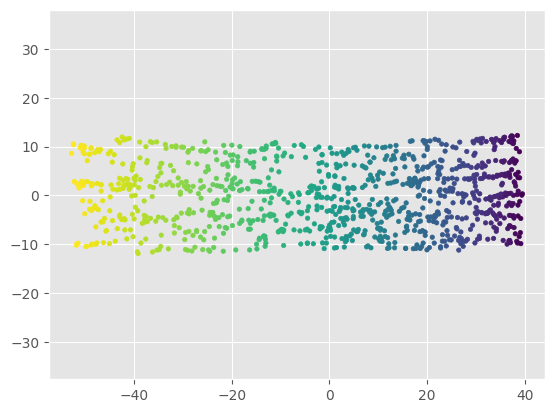

In [8]:
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.show()